# Part 1: CNN-Based Encoding Models (20 Marks)

Compare ResNet-50, EfficientNet-B0, and SqueezeNet for predicting brain responses.

**Subject:** 02  
**ROI:** Place-selective regions (floc-places) - OPA, PPA, RSC

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
from torchvision import models, transforms
import json
import warnings
warnings.filterwarnings('ignore')

# Import shared utilities
from utils import (get_paths, load_fmri_data, load_roi_masks, 
                   get_roi_vertices, get_image_paths, train_encoding_model, device)

print(f"Using device: {device}")

Using device: cuda


In [9]:
# Configuration
BASE_DIR = r'c:\Users\evanb\OneDrive\Documents\Studies\SEM6\CSAI\A2\neuroai-visual-encoder'
paths = get_paths(BASE_DIR)
N_VERTICES = 10
BATCH_SIZE = 32

In [3]:
# Load data
print("Loading fMRI data...")
fmri_data = load_fmri_data(paths)

print("\nLoading ROI masks...")
roi_masks = load_roi_masks(paths)

print("\nSelecting vertices per ROI...")
roi_data = get_roi_vertices(roi_masks, fmri_data, N_VERTICES)

if not roi_data:
    raise RuntimeError("No ROI data found! Check that roi_masks has valid floc-places regions.")

print("\nLoading image paths...")
train_images = get_image_paths(paths['train_img'])
test_images = get_image_paths(paths['test_img'])

if len(train_images) == 0 or len(test_images) == 0:
    raise RuntimeError(f"No images found! train={len(train_images)}, test={len(test_images)}")

print(f"Training images: {len(train_images)}, Test images: {len(test_images)}")
print(f"\n✓ Data loaded successfully! ROIs: {list(roi_data.keys())}")

Loading fMRI data...
Training fMRI - LH: (9841, 19004), RH: (9841, 20544)
Test fMRI - LH: (159, 19004), RH: (159, 20544)

Loading ROI masks...
ROI masks - LH: (19004,), RH: (20544,)
ROI mapping: {0: 'Unknown', 1: 'OPA', 2: 'PPA', 3: 'RSC'}

Selecting vertices per ROI...

OPA: LH has 1494 vertices, RH has 2434 vertices
  Selected 10 LH + 0 RH vertices

PPA: LH has 1272 vertices, RH has 1490 vertices
  Selected 10 LH + 0 RH vertices

RSC: LH has 481 vertices, RH has 683 vertices
  Selected 10 LH + 0 RH vertices

Loading image paths...
Training images: 9841, Test images: 159

✓ Data loaded successfully! ROIs: ['OPA', 'PPA', 'RSC']


## CNN Feature Extractor

In [4]:
class CNNFeatureExtractor:
    """Extract features from CNN architectures."""
    
    def __init__(self, model_name='resnet50'):
        self.model_name = model_name
        self.model, self.preprocess = self._load_model(model_name)
        self.model.eval()
        self.model.to(device)
        
    def _load_model(self, model_name):
        preprocess = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        if model_name == 'resnet50':
            model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
            model = nn.Sequential(*list(model.children())[:-1])
        elif model_name == 'efficientnet_b0':
            model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
            model = nn.Sequential(*list(model.children())[:-1])
        elif model_name == 'squeezenet':
            model = models.squeezenet1_1(weights=models.SqueezeNet1_1_Weights.IMAGENET1K_V1)
            model = model.features
        else:
            raise ValueError(f"Unknown model: {model_name}")
        
        return model, preprocess
    
    def extract_features(self, image_paths, batch_size=32):
        features = []
        
        with torch.no_grad():
            for i in tqdm(range(0, len(image_paths), batch_size), desc=f"{self.model_name}"):
                batch_paths = image_paths[i:i+batch_size]
                batch_imgs = [self.preprocess(Image.open(p).convert('RGB')) for p in batch_paths]
                batch_tensor = torch.stack(batch_imgs).to(device)
                batch_features = self.model(batch_tensor)
                batch_features = batch_features.view(batch_features.size(0), -1)
                features.append(batch_features.cpu().numpy())
        
        return np.vstack(features)

## Extract Features from All CNNs

In [5]:
cnn_models = ['resnet50', 'efficientnet_b0', 'squeezenet']
cnn_features = {}

for model_name in cnn_models:
    print(f"\nExtracting features with {model_name}...")
    extractor = CNNFeatureExtractor(model_name)
    
    train_feats = extractor.extract_features(train_images, batch_size=BATCH_SIZE)
    test_feats = extractor.extract_features(test_images, batch_size=BATCH_SIZE)
    
    cnn_features[model_name] = {'train': train_feats, 'test': test_feats}
    print(f"  Train: {train_feats.shape}, Test: {test_feats.shape}")
    
    del extractor
    torch.cuda.empty_cache() if torch.cuda.is_available() else None


Extracting features with resnet50...


resnet50: 100%|██████████| 5/5 [00:01<00:00,  2.91it/s]


  Train: (9841, 2048), Test: (159, 2048)

Extracting features with efficientnet_b0...


efficientnet_b0: 100%|██████████| 5/5 [00:01<00:00,  3.04it/s]


  Train: (9841, 1280), Test: (159, 1280)

Extracting features with squeezenet...


squeezenet: 100%|██████████| 5/5 [00:02<00:00,  2.39it/s]

  Train: (9841, 86528), Test: (159, 86528)


## Train Encoding Models

In [6]:
cnn_results = {model: {} for model in cnn_models}

print("Training encoding models...\n")
for model_name in cnn_models:
    print(f"\n{model_name.upper()}")
    print("="*40)
    
    for roi_name, roi_info in roi_data.items():
        correlations, mean_corr, _ = train_encoding_model(
            cnn_features[model_name]['train'],
            roi_info['train'],
            cnn_features[model_name]['test'],
            roi_info['test'],
            alpha=1000
        )
        
        cnn_results[model_name][roi_name] = {
            'correlations': correlations.tolist(),
            'mean': float(mean_corr)
        }
        print(f"  {roi_name}: Mean r = {mean_corr:.4f}")

Training encoding models...


RESNET50
  OPA: Mean r = 0.4451
  PPA: Mean r = 0.5547
  RSC: Mean r = 0.5074

EFFICIENTNET_B0
  OPA: Mean r = 0.3890
  PPA: Mean r = 0.5093
  RSC: Mean r = 0.4860

SQUEEZENET
  OPA: Mean r = 0.3310
  PPA: Mean r = 0.4757
  RSC: Mean r = 0.4252


## Visualization

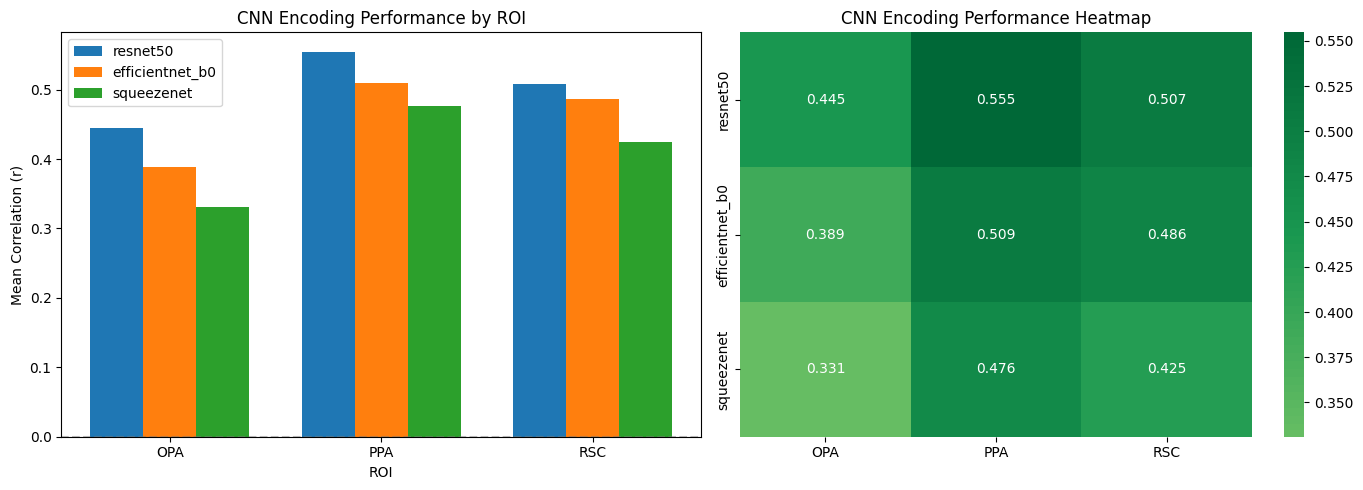


Best CNN model per ROI:
  OPA: resnet50 (r = 0.4451)
  PPA: resnet50 (r = 0.5547)
  RSC: resnet50 (r = 0.5074)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

roi_names = list(roi_data.keys())
x = np.arange(len(roi_names))
width = 0.25

for i, model_name in enumerate(cnn_models):
    means = [cnn_results[model_name][roi]['mean'] for roi in roi_names]
    axes[0].bar(x + i*width, means, width, label=model_name)

axes[0].set_xlabel('ROI')
axes[0].set_ylabel('Mean Correlation (r)')
axes[0].set_title('CNN Encoding Performance by ROI')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(roi_names)
axes[0].legend()
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Heatmap
heatmap_data = np.array([[cnn_results[m][r]['mean'] for r in roi_names] for m in cnn_models])
sns.heatmap(heatmap_data, annot=True, fmt='.3f', xticklabels=roi_names, 
            yticklabels=cnn_models, cmap='RdYlGn', center=0, ax=axes[1])
axes[1].set_title('CNN Encoding Performance Heatmap')

plt.tight_layout()
plt.savefig('part1_cnn_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBest CNN model per ROI:")
for roi in roi_names:
    best_model = max(cnn_models, key=lambda m: cnn_results[m][roi]['mean'])
    print(f"  {roi}: {best_model} (r = {cnn_results[best_model][roi]['mean']:.4f})")

## Save Results

In [8]:
# Save for comparison with other parts
with open('part1_cnn_results.json', 'w') as f:
    json.dump(cnn_results, f, indent=2)
print("Results saved to part1_cnn_results.json")

Results saved to part1_cnn_results.json


## Discussion

**Analysis:**
- Place-selective regions (OPA, PPA, RSC) are involved in scene/spatial processing
- Different CNN architectures have varying depths and receptive fields
- ResNet-50's residual connections may capture hierarchical scene features
- EfficientNet's compound scaling balances local and global features
- SqueezeNet is lighter but may miss fine-grained spatial details

**Hypothesis:** Deeper networks (ResNet, EfficientNet) should perform better on place-selective regions as these areas respond to complex scene layouts requiring hierarchical processing.